In [1]:
!unzip -q "/content/archive (8).zip" -d "/content/fashion_data"

In [2]:
import os

for root, dirs, files in os.walk("/content/fashion_data"):
    print(root)
    print("Files:", len(files))
    print("-"*50)

/content/fashion_data
Files: 1
--------------------------------------------------
/content/fashion_data/images
Files: 44441
--------------------------------------------------
/content/fashion_data/myntradataset
Files: 1
--------------------------------------------------
/content/fashion_data/myntradataset/images
Files: 44441
--------------------------------------------------


In [30]:
import pandas as pd

df = pd.read_csv(
    "/content/fashion_data/styles.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [5]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


np.int64(0)

In [6]:
df['articleType'].value_counts().head(10)

,count
articleType,
Tshirts,7067
Shirts,3217
Casual Shoes,2845
Watches,2542
Sports Shoes,2036
Kurtas,1844
Tops,1762
Handbags,1759
Heels,1323


In [23]:
df['articleType'].nunique()

123

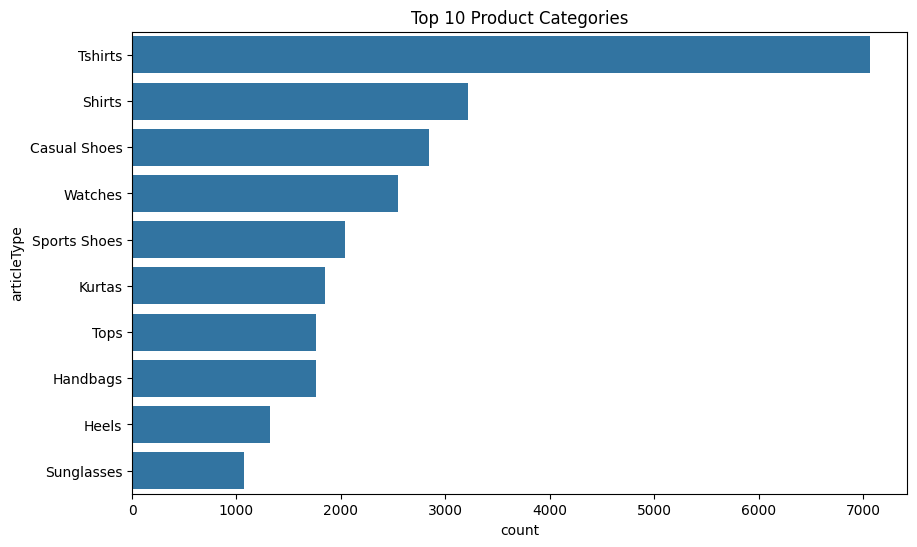

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.countplot(
    y='articleType',
    data=df,
    order=df['articleType'].value_counts().head(10).index
)

plt.title("Top 10 Product Categories")
plt.show()

In [25]:
top_categories = (
    df['articleType']
    .value_counts()
    .head(10)
    .index
)

df = df[
    df['articleType'].isin(top_categories)
]

In [26]:
print(df.shape)

print(df['articleType'].nunique())

(25465, 3)
10


In [27]:
df = df.sample(
    n=5000,
    random_state=42
)

In [28]:
print(df.shape)

(5000, 3)


In [31]:
import os

image_dir = "/content/fashion_data/images"

df['image_path'] = df['id'].astype(str).apply(
    lambda x: os.path.join(
        image_dir,
        x + ".jpg"
    )
)

In [32]:
print(df.columns.tolist())

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']


In [33]:
df = df[['image_path','articleType']]

In [34]:
df.dropna(inplace=True)

In [35]:
top_categories = (
    df['articleType']
    .value_counts()
    .head(10)
    .index
)

df = df[
    df['articleType'].isin(top_categories)
]

print(df.shape)
print(df['articleType'].nunique())

(25468, 2)
10


In [36]:
df = df.sample(
    n=5000,
    random_state=42
)

print(df.shape)

(5000, 2)


In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(
    df['articleType']
)

num_classes = df['label'].nunique()

print(num_classes)

10


In [38]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print(train_df.shape)
print(test_df.shape)

(4000, 3)
(1000, 3)


In [39]:
print(train_df.shape)
print(test_df.shape)
print(num_classes)

(4000, 3)
(1000, 3)
10


In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [41]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(128,128),
    batch_size=32,
    class_mode='raw'
)

Found 4000 validated image filenames.


In [42]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(128,128),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)

Found 1000 validated image filenames.


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        num_classes,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,610 (28.20 MB)

 Trainable params: 7,393,610 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=3
)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 114s 893ms/step - accuracy: 0.6538 - loss: 1.1315 - val_accuracy: 0.7900 - val_loss: 0.6099
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 110s 882ms/step - accuracy: 0.8407 - loss: 0.4362 - val_accuracy: 0.8190 - val_loss: 0.4985
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 972ms/step - accuracy: 0.8860 - loss: 0.3147 - val_accuracy: 0.8340 - val_loss: 0.4535


In [47]:
loss, accuracy = model.evaluate(
    test_generator
)

print("Test Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.8340 - loss: 0.4535
Test Accuracy: 0.8339999914169312


In [54]:
import numpy as np

pred_probs = model.predict(
    test_generator
)

confidence = np.max(
    pred_probs,
    axis=1
)



32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 384ms/step


In [49]:
manual_review = confidence < 0.80

print(
    "Images requiring manual review:",
    manual_review.sum()
)

Images requiring manual review: 274


In [59]:
import numpy as np

predicted_class = np.argmax(pred_probs[0])

print(predicted_class)

5


In [60]:
confidence = np.max(pred_probs[0])

print(confidence)

0.7028832


1. What business problem was solved?

A CNN-based image classification system was developed to automatically categorize fashion product images uploaded by vendors, reducing manual catalog management effort.

2. Which variables influenced the outcome most?

The CNN learned visual features from images such as:

Shape
Color
Texture
Patterns and design elements

These features helped distinguish between different product categories.

3. What insights were discovered?
Most product images can be automatically categorized.
High-confidence predictions can be processed without human intervention.
Some images require manual verification due to low confidence scores.
Product image quality significantly affects classification accuracy.
4. What risks exist in deployment?
Blurry or poor-quality images.
Incorrect product uploads by vendors.
New product categories not present in training data.
Misclassification of visually similar products.
5. What final recommendation would you provide to management?

Deploy the CNN model for automatic product categorization. Images with confidence scores below 80% should be routed for manual verification, while high-confidence predictions can be automatically added to the catalog. This approach will improve catalog quality, reduce manual effort, and enhance customer experience.